# Overture API POI-to-Building Analysis

This notebook mirrors the earlier AOI enrichment workflow, but it uses only Overture APIs and cloud-hosted release artifacts. The workflow fetches the latest Overture release from STAC, uses a local AOI polygon to derive a query bounding box, pulls `places` and `buildings`, filters them back to the exact AOI shape, assigns POIs to buildings, and visualizes the result with a compact top-category rollup.

## Table of Contents
- [Assumptions and References](#Assumptions-and-References)
- [Step 1: Fetch Overture Places and Buildings for the AOI](#Step-1:-Fetch-Overture-Places-and-Buildings-for-the-AOI)
- [Step 2: Assign POIs to Buildings](#Step-2:-Assign-POIs-to-Buildings)
- [Step 3: Build a Compact Category Rollup](#Step-3:-Build-a-Compact-Category-Rollup)
- [Step 4: Static Analysis and Visualization](#Step-4:-Static-Analysis-and-Visualization)
- [Step 5: Interactive Map and HTML Export](#Step-5:-Interactive-Map-and-HTML-Export)


## Assumptions and References

- The analysis is API-only for Overture data access: release discovery uses the Overture STAC catalog and feature access uses Overture's cloud-hosted GeoParquet endpoints through DuckDB.
- The AOI comes from `data/canary_wharf.geojson`, reprojected to EPSG:4326 and merged into one analysis geometry if the file contains multiple features.
- Overture's docs recommend bounding-box extraction for modest AOIs and DuckDB for direct querying of cloud-hosted GeoParquet, so this notebook queries by the AOI bounding box first and then filters to the exact polygon.
- Overture's places taxonomy docs note that `taxonomy.hierarchy` runs from top-level (L0) down to the primary category, which makes it the right backbone for category generalization.

Docs used:
- https://docs.overturemaps.org/getting-data/
- https://docs.overturemaps.org/blog/2026/02/11/stac/
- https://docs.overturemaps.org/guides/places/
- https://docs.overturemaps.org/guides/places/taxonomy/
- https://docs.overturemaps.org/schema/reference/places/place/
- https://docs.overturemaps.org/guides/buildings/


In [1]:
from pathlib import Path
import html
import json
from typing import Any, cast

import duckdb
import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from folium.plugins import MarkerCluster
from shapely import from_wkb
from shapely.geometry import Point
from shapely.geometry.base import BaseGeometry


In [2]:
pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

project_root = Path.cwd()
if project_root.name == 'code':
    project_root = project_root.parent

code_dir = project_root / 'code'
data_dir = project_root / 'data'
output_dir = project_root / 'output'
code_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

aoi_path = data_dir / 'canary_wharf.geojson'
if not aoi_path.exists():
    raise FileNotFoundError(f'AOI file not found: {aoi_path}')

aoi_name = 'Canary Wharf'
top_n_display_categories = 8
nearest_building_distance_m = 15
max_poi_markers = 1200
export_map_html = True

aoi_source = gpd.read_file(aoi_path)
if aoi_source.empty:
    raise ValueError(f'AOI file contains no features: {aoi_path}')

if aoi_source.crs is None:
    aoi_source = aoi_source.set_crs('EPSG:4326')
else:
    aoi_source = aoi_source.to_crs('EPSG:4326')

aoi_geometry = cast(BaseGeometry, aoi_source.geometry.union_all())
aoi = gpd.GeoDataFrame(
    {'aoi_name': [aoi_name]},
    geometry=gpd.GeoSeries([aoi_geometry], crs='EPSG:4326'),
    crs='EPSG:4326',
)
west, south, east, north = aoi.total_bounds
aoi_bbox = {
    'west': float(west),
    'south': float(south),
    'east': float(east),
    'north': float(north),
}

display(aoi)


,aoi_name,geometry
0,Canary Wharf,"POLYGON ((-0.02475 51.50053, -0.02492 51.50052..."


In [3]:
def init_overture_connection() -> tuple[duckdb.DuckDBPyConnection, str]:
    con = duckdb.connect()
    for statement in [
        'INSTALL spatial',
        'INSTALL httpfs',
        'LOAD spatial',
        'LOAD httpfs',
        "SET s3_region='us-west-2'",
    ]:
        con.execute(statement)

    latest_release = con.execute(
        "SELECT latest FROM 'https://stac.overturemaps.org/catalog.json'"
    ).fetchone()
    if latest_release is None:
        raise RuntimeError('Could not read the latest Overture release from STAC.')
    release_name = str(latest_release[0])
    return con, release_name


def parquet_path(release: str, theme: str, type_name: str) -> str:
    return (
        f's3://overturemaps-us-west-2/release/{release}'
        f'/theme={theme}/type={type_name}/*'
    )


def parse_wkb(value: object) -> BaseGeometry:
    if value is None:
        raise TypeError('Geometry WKB value cannot be None.')
    if isinstance(value, memoryview):
        value = value.tobytes()
    if isinstance(value, bytearray):
        value = bytes(value)
    if isinstance(value, bytes):
        return cast(BaseGeometry, from_wkb(value))
    raise TypeError(f'Unsupported WKB value type: {type(value)!r}')


def wkb_df_to_gdf(
    df: pd.DataFrame,
    geometry_col: str = 'geometry_wkb',
    crs: str = 'EPSG:4326',
) -> gpd.GeoDataFrame:
    geometry_values: list[BaseGeometry] = [parse_wkb(value) for value in df[geometry_col].tolist()]
    geometry = gpd.GeoSeries(geometry_values, crs=crs)
    gdf = gpd.GeoDataFrame(df.drop(columns=[geometry_col]).copy(), geometry=geometry, crs=crs)
    return gdf


def is_missing_scalar(value: object) -> bool:
    if value is None or value is pd.NA:
        return True
    if isinstance(value, float):
        return bool(np.isnan(value))
    if isinstance(value, np.floating):
        return bool(np.isnan(float(value)))
    return False


def parse_taxonomy_json(value: object) -> dict[str, Any] | None:
    if is_missing_scalar(value):
        return None
    if isinstance(value, str):
        if value.strip() == '':
            return None
        parsed = json.loads(value)
        return cast(dict[str, Any], parsed) if isinstance(parsed, dict) else None
    if isinstance(value, dict):
        return cast(dict[str, Any], value)
    return None


def slug_to_label(value: object) -> str:
    if is_missing_scalar(value):
        return 'Unknown'
    text_value = str(value)
    if text_value == '':
        return 'Unknown'
    return text_value.replace('_', ' ').title()


def as_text(value: object, default: str = 'Unknown') -> str:
    if is_missing_scalar(value):
        return default
    text_value = str(value)
    return default if text_value == '' else text_value


def as_int(value: object, default: int = 0) -> int:
    if is_missing_scalar(value):
        return default
    if isinstance(value, bool):
        return int(value)
    if isinstance(value, (int, np.integer)):
        return int(value)
    if isinstance(value, (float, np.floating)):
        return default if np.isnan(float(value)) else int(value)
    if isinstance(value, str):
        stripped_value = value.strip()
        if stripped_value == '':
            return default
        try:
            return int(float(stripped_value))
        except ValueError:
            return default
    return default


def as_str_list(value: object) -> list[str]:
    if isinstance(value, list):
        return [str(item) for item in value]
    return []


def series_text(row: pd.Series, key: str, default: str = 'Unknown') -> str:
    return as_text(row.get(key), default=default)


def series_geometry(row: pd.Series, key: str = 'geometry') -> BaseGeometry | None:
    geometry_value = row.get(key)
    if geometry_value is None:
        return None
    return cast(BaseGeometry, geometry_value)


def series_hierarchy(row: pd.Series, key: str = 'taxonomy_hierarchy') -> list[str]:
    value = row.get(key)
    if isinstance(value, list):
        return [str(item) for item in value if item]
    return []


def taxonomy_primary(value: dict[str, Any] | None) -> str | None:
    if value is None:
        return None
    primary = value.get('primary')
    return str(primary) if primary is not None else None


def taxonomy_hierarchy(value: dict[str, Any] | None) -> list[str]:
    if value is None:
        return []
    hierarchy = value.get('hierarchy', [])
    if isinstance(hierarchy, list):
        return [str(item) for item in hierarchy if item]
    return []


def build_building_tooltip(row: pd.Series) -> str:
    building_id = series_text(row, 'id', default='n/a')
    poi_sum = as_int(row.get('poi_sum'))
    dominant_category = series_text(row, 'dominant_category', default='No matched POIs')
    return f'building_id: {building_id} | poi_sum: {poi_sum} | dominant: {dominant_category}'


def build_poi_tooltip(row: pd.Series) -> str:
    primary_name = series_text(row, 'primary_name')
    basic_category = series_text(row, 'basic_category')
    compact_category = series_text(row, 'analysis_category_limited')
    match_method = series_text(row, 'building_match_method')
    return (
        f"<b>Name:</b> {html.escape(primary_name)}<br>"
        f"<b>Basic category:</b> {html.escape(basic_category)}<br>"
        f"<b>Compact category:</b> {html.escape(compact_category)}<br>"
        f"<b>Match method:</b> {html.escape(match_method)}"
    )


def point_from_row(row: pd.Series) -> Point | None:
    geometry_value = series_geometry(row)
    if geometry_value is None or geometry_value.is_empty or geometry_value.geom_type != 'Point':
        return None
    return cast(Point, geometry_value)



## Step 1: Fetch Overture Places and Buildings for the AOI

This step follows the Overture quickstart pattern: query the latest release through STAC, derive a bounding box from the AOI polygon, then read only that slice of the `places/place` and `buildings/building` datasets through DuckDB before filtering back to the exact AOI shape.


In [4]:
con, latest_release = init_overture_connection()

west = aoi_bbox['west']
south = aoi_bbox['south']
east = aoi_bbox['east']
north = aoi_bbox['north']

places_query = f"""
SELECT
    id,
    names.primary AS primary_name,
    basic_category,
    CAST(taxonomy AS JSON) AS taxonomy_json,
    confidence,
    operating_status,
    ST_AsWKB(geometry) AS geometry_wkb
FROM read_parquet(
    '{parquet_path(latest_release, 'places', 'place')}',
    filename=true,
    hive_partitioning=1
)
WHERE
    bbox.xmin BETWEEN {west} AND {east}
    AND bbox.ymin BETWEEN {south} AND {north}
    AND coalesce(operating_status, 'open') <> 'permanently_closed'
    AND coalesce(confidence, 1.0) > 0
"""

buildings_query = f"""
SELECT
    id,
    names.primary AS building_name,
    class AS building_class,
    subtype AS building_subtype,
    height,
    num_floors,
    ST_AsWKB(geometry) AS geometry_wkb
FROM read_parquet(
    '{parquet_path(latest_release, 'buildings', 'building')}',
    filename=true,
    hive_partitioning=1
)
WHERE
    bbox.xmin <= {east}
    AND bbox.xmax >= {west}
    AND bbox.ymin <= {north}
    AND bbox.ymax >= {south}
"""

places_raw = con.execute(places_query).df()
buildings_raw = con.execute(buildings_query).df()

print(f'Latest Overture release: {latest_release}')
print(f'Places fetched from remote API/storage: {len(places_raw):,}')
print(f'Buildings fetched from remote API/storage: {len(buildings_raw):,}')


Latest Overture release: 2026-03-18.0
Places fetched from remote API/storage: 3,135
Buildings fetched from remote API/storage: 1,120


In [5]:
place_aoi_filtered = wkb_df_to_gdf(places_raw)
building_aoi_filtered = wkb_df_to_gdf(buildings_raw)

place_aoi_filtered['taxonomy_json'] = place_aoi_filtered['taxonomy_json'].map(parse_taxonomy_json)
place_aoi_filtered['taxonomy_hierarchy'] = place_aoi_filtered['taxonomy_json'].map(taxonomy_hierarchy)
place_aoi_filtered['taxonomy_primary'] = place_aoi_filtered['taxonomy_json'].map(taxonomy_primary)
place_aoi_filtered['taxonomy_l0'] = place_aoi_filtered['taxonomy_hierarchy'].map(
    lambda values: values[0] if isinstance(values, list) and len(values) > 0 else None
)

place_aoi_filtered = place_aoi_filtered[place_aoi_filtered.intersects(aoi_geometry)].copy()
building_aoi_filtered = building_aoi_filtered[building_aoi_filtered.intersects(aoi_geometry)].copy()

place_aoi = place_aoi_filtered.copy()
building_aoi = building_aoi_filtered.copy()

display(
    pd.DataFrame(
        {
            'layer': ['place_aoi', 'building_aoi'],
            'rows': [len(place_aoi), len(building_aoi)],
            'crs': [str(place_aoi.crs), str(building_aoi.crs)],
        }
    )
)

display(
    pd.DataFrame(
        {
            'place_aoi_fields': pd.Series(place_aoi.columns, dtype='string'),
            'building_aoi_fields': pd.Series(building_aoi.columns, dtype='string'),
        }
    )
)

display(place_aoi.head(3))
display(building_aoi.head(3))


,layer,rows,crs
0,place_aoi,2461,EPSG:4326
1,building_aoi,439,EPSG:4326


,place_aoi_fields,building_aoi_fields
0,id,id
1,primary_name,building_name
2,basic_category,building_class
3,taxonomy_json,building_subtype
4,confidence,height
5,operating_status,num_floors
6,geometry,geometry
7,taxonomy_hierarchy,<NA>
8,taxonomy_primary,<NA>
9,taxonomy_l0,<NA>


,id,primary_name,basic_category,taxonomy_json,confidence,operating_status,geometry,taxonomy_hierarchy,taxonomy_primary,taxonomy_l0
1,57d23081-fe25-41fc-8140-d9c8af98b28c,Mendoza Contract Cleaning,home_service,"{'primary': 'home_cleaning', 'hierarchy': ['se...",0.938874,open,POINT (-0.02055 51.50095),"[services_and_business, home_service, home_cle...",home_cleaning,services_and_business
2,b46891ea-3e2a-485c-9fb2-4a0e94cfffa5,Bella Cosa Restaurant,restaurant,"{'primary': 'italian_restaurant', 'hierarchy':...",0.998116,open,POINT (-0.01227 51.50067),"[food_and_drink, restaurant, european_restaura...",italian_restaurant,food_and_drink
3,3309baca-349e-4208-a9c1-e3b4174d8093,Vectone Mobile,corporate_or_business_office,"{'primary': 'corporate_office', 'hierarchy': [...",0.770000,open,POINT (-0.021 51.50083),"[services_and_business, private_establishments...",corporate_office,services_and_business


,id,building_name,building_class,building_subtype,height,num_floors,geometry
4,362eb072-7da0-4b30-a066-b34b7036398f,NaN,NaN,NaN,NaN,<NA>,"POLYGON ((-0.0227 51.5008, -0.0229 51.50084, -..."
7,817735f9-1eb0-4207-abe7-89dfd839e6a0,Scott House,commercial,commercial,NaN,4,"POLYGON ((-0.02067 51.50169, -0.02087 51.50171..."
16,dee5ba4c-e600-4ac1-a8f4-d748a666a19d,NaN,NaN,NaN,NaN,<NA>,"POLYGON ((-0.01432 51.50069, -0.01445 51.50071..."


## Step 2: Assign POIs to Buildings

The matching logic uses a two-stage approach:

1. `within` the building footprint first.
2. For unmatched POIs, use `sjoin_nearest` with a small metric threshold to catch entrance-point and curbside placement errors.

This is usually a better urban analysis strategy than strict containment only.


In [6]:
analysis_crs = building_aoi.estimate_utm_crs()
if analysis_crs is None:
    raise ValueError('Could not estimate a projected CRS for the AOI.')

place_metric = place_aoi.to_crs(analysis_crs)
building_metric = building_aoi.to_crs(analysis_crs).copy()
building_metric['building_area_m2'] = building_metric.area

place_metric_points = gpd.GeoDataFrame(
    place_metric[['geometry']].copy(),
    geometry='geometry',
    crs=analysis_crs,
)
building_metric_polygons = gpd.GeoDataFrame(
    building_metric[['id', 'building_area_m2', 'geometry']].copy(),
    geometry='geometry',
    crs=analysis_crs,
)

within_join = gpd.sjoin(
    place_metric_points,
    building_metric_polygons,
    how='left',
    predicate='within',
).reset_index(names='place_index')

within_best = (
    within_join.dropna(subset=['id'])
    .sort_values(['place_index', 'building_area_m2'])
    .drop_duplicates(subset='place_index')
    .rename(columns={'id': 'building_id'})[['place_index', 'building_id']]
)
within_best['building_match_method'] = 'within'
within_best['snap_distance_m'] = 0.0

place_assignments = within_best.copy()
matched_place_index_set = set(place_assignments['place_index'].tolist())
unmatched_index_list = [index_value for index_value in place_aoi.index.tolist() if index_value not in matched_place_index_set]

if len(unmatched_index_list) > 0:
    unmatched_points = gpd.GeoDataFrame(
        place_metric.loc[unmatched_index_list, ['geometry']].copy(),
        geometry='geometry',
        crs=analysis_crs,
    )
    building_metric_nearest = gpd.GeoDataFrame(
        building_metric[['id', 'geometry']].copy(),
        geometry='geometry',
        crs=analysis_crs,
    )
    nearest_join = gpd.sjoin_nearest(
        unmatched_points,
        building_metric_nearest,
        how='left',
        max_distance=nearest_building_distance_m,
        distance_col='snap_distance_m',
    ).reset_index(names='place_index')

    nearest_best = (
        nearest_join.dropna(subset=['id'])
        .sort_values(['place_index', 'snap_distance_m'])
        .drop_duplicates(subset='place_index')
        .rename(columns={'id': 'building_id'})[['place_index', 'building_id', 'snap_distance_m']]
    )
    nearest_best['building_match_method'] = 'nearest'
    place_assignments = pd.concat([place_assignments, nearest_best], ignore_index=True)

place_aoi = place_aoi.merge(place_assignments, left_index=True, right_on='place_index', how='left')
place_aoi = place_aoi.set_index('place_index').sort_index()
place_aoi['building_match_method'] = place_aoi['building_match_method'].fillna('unmatched')
place_aoi['is_assigned_to_building'] = place_aoi['building_id'].notna()
place_aoi = gpd.GeoDataFrame(place_aoi, geometry='geometry', crs='EPSG:4326')
place_aoi.columns = pd.Index([str(column) for column in place_aoi.columns], dtype='object')

building_lookup = pd.DataFrame(
    building_aoi.loc[:, ['id', 'building_name', 'building_class', 'building_subtype', 'height', 'num_floors']].copy()
)
building_lookup = building_lookup.rename(columns={'id': 'building_id'})
place_aoi = place_aoi.merge(building_lookup, on='building_id', how='left')
place_aoi = gpd.GeoDataFrame(place_aoi, geometry='geometry', crs='EPSG:4326')
place_aoi.columns = pd.Index([str(column) for column in place_aoi.columns], dtype='object')

coverage_summary = pd.DataFrame(
    {
        'poi_count': place_aoi['building_match_method'].value_counts().reindex(
            ['within', 'nearest', 'unmatched'],
            fill_value=0,
        )
    }
)
coverage_summary['share_pct'] = coverage_summary['poi_count'] / len(place_aoi) * 100
display(coverage_summary)


,poi_count,share_pct
building_match_method,,
within,1540,62.576189
nearest,743,30.190979
unmatched,178,7.232832


## Step 3: Build a Compact Category Rollup

Overture's `basic_category` is great for human-readable labels, but there are still a few hundred possible values. The most stable way to generalize is to use `taxonomy.hierarchy` from the top level down. For map analysis, this notebook adds two intentional overrides:

- `Hotels` are kept separate because they matter as a distinct urban land-use signal.
- `Parks` are kept separate because green/open-space amenities are analytically useful even when the broader taxonomy is more general.

After that rollup, only the top `N` analysis categories are kept for display; the rest collapse into `Other`.


In [7]:
hotel_categories = {
    'bed_and_breakfast',
    'guest_house',
    'hostel',
    'hotel',
    'inn',
    'motel',
    'resort_hotel',
    'serviced_accommodation',
}

park_categories = {
    'botanical_garden',
    'campground',
    'dog_park',
    'garden',
    'national_park',
    'park',
    'picnic_area',
    'playground',
    'recreation_ground',
    'rv_park',
    'state_park',
}

service_l0_categories = {
    'business_to_business',
    'financial_service',
    'home_service',
    'professional_services',
}


def derive_analysis_category(row: pd.Series) -> str:
    basic = row.get('basic_category')
    primary = row.get('taxonomy_primary')
    hierarchy = series_hierarchy(row)
    l0 = row.get('taxonomy_l0')

    hierarchy_values = {value for value in hierarchy if value}

    if basic in hotel_categories or primary in hotel_categories or hierarchy_values.intersection(hotel_categories):
        return 'Hotels'
    if basic in park_categories or primary in park_categories or hierarchy_values.intersection(park_categories):
        return 'Parks'
    if l0 == 'food_and_drink':
        return 'Food & Drink'
    if l0 == 'public_service_and_government':
        return 'Government'
    if l0 in service_l0_categories:
        return 'Services'
    if l0 == 'health_and_medical':
        return 'Health & Medical'
    if l0 == 'education':
        return 'Education'
    if l0 == 'retail':
        return 'Retail'
    if l0 == 'arts_and_entertainment':
        return 'Arts & Entertainment'
    if l0 == 'attractions_and_activities':
        return 'Attractions & Activities'
    if l0 == 'travel':
        return 'Travel'
    if l0 == 'transportation':
        return 'Transportation'
    return slug_to_label(l0 or basic or 'unknown')


analysis_category_series = place_aoi.apply(derive_analysis_category, axis=1).astype('string')
place_aoi['analysis_category'] = analysis_category_series

assigned_places = place_aoi[place_aoi['is_assigned_to_building']].copy()
assigned_analysis_category = cast(pd.Series, assigned_places['analysis_category'])
analysis_category_counts = assigned_analysis_category.value_counts()
kept_categories = analysis_category_counts.head(top_n_display_categories).index.tolist()

analysis_category_keep_mask = cast(pd.Series, analysis_category_series.isin(kept_categories))
analysis_category_limited = analysis_category_series.copy()
analysis_category_limited.loc[~analysis_category_keep_mask] = 'Other'
analysis_category_limited = analysis_category_limited.astype('string')
place_aoi['analysis_category_limited'] = analysis_category_limited

assigned_places = place_aoi[place_aoi['is_assigned_to_building']].copy()
assigned_analysis_category_limited = cast(pd.Series, assigned_places['analysis_category_limited'])
display(assigned_analysis_category_limited.value_counts().to_frame('poi_count'))


,poi_count
analysis_category_limited,
Services And Business,1081
Food & Drink,344
Shopping,273
Other,164
Health Care,110
Travel And Transportation,106
Education,80
Lifestyle Services,74
Sports And Recreation,51


In [8]:
building_category_counts = (
    assigned_places.groupby(['building_id', 'analysis_category_limited'])
    .size()
    .unstack(fill_value=0)
)

category_columns = [str(column) for column in building_category_counts.columns.tolist()]
building_crs = building_aoi.crs
building_aoi = gpd.GeoDataFrame(
    pd.DataFrame(building_aoi).merge(building_category_counts, left_on='id', right_index=True, how='left'),
    geometry='geometry',
    crs=building_crs,
)
building_aoi.columns = pd.Index([str(column) for column in building_aoi.columns], dtype='object')

category_frame = pd.DataFrame(index=building_aoi.index)
for column in category_columns:
    category_frame[column] = pd.Series(
        [as_int(value) for value in building_aoi[column]],
        index=building_aoi.index,
        dtype='int64',
    )
    building_aoi[column] = category_frame[column]

if category_columns:
    category_matrix = category_frame.to_numpy(dtype='int64', copy=True)
    poi_sum_series = pd.Series(category_matrix.sum(axis=1), index=building_aoi.index, dtype='int64')
    building_aoi['poi_sum'] = poi_sum_series

    positive_poi_mask = poi_sum_series.gt(0)
    dominant_position = category_matrix.argmax(axis=1)
    dominant_category_series = pd.Series(
        [category_columns[position] for position in dominant_position],
        index=building_aoi.index,
        dtype='string',
    )
    dominant_category_series.loc[~positive_poi_mask] = 'No matched POIs'
    building_aoi['dominant_category'] = dominant_category_series

    dominant_counts = pd.Series(category_matrix.max(axis=1), index=building_aoi.index, dtype='float64')
    dominant_share_series = dominant_counts.div(poi_sum_series.replace(0, np.nan)).mul(100)
    dominant_share_series.loc[~positive_poi_mask] = np.nan
    building_aoi['dominant_share_pct'] = dominant_share_series
else:
    building_aoi['poi_sum'] = pd.Series(0, index=building_aoi.index, dtype='int64')
    building_aoi['dominant_category'] = pd.Series('No matched POIs', index=building_aoi.index, dtype='string')
    building_aoi['dominant_share_pct'] = np.nan

top_places_lookup: dict[str, list[str]] = {}
for building_id, values in assigned_places.groupby('building_id')['primary_name']:
    top_places_lookup[str(building_id)] = [value for value in pd.Series(values).dropna().astype(str).unique()[:8]]

building_aoi['sample_place_names'] = [
    as_str_list(top_places_lookup.get(str(building_id), []))
    for building_id in building_aoi['id']
]

building_summary = building_aoi.loc[building_aoi['poi_sum'] > 0, ['id', 'building_name', 'poi_sum', 'dominant_category', 'dominant_share_pct']]
display(building_summary.sort_values(['poi_sum', 'dominant_share_pct'], ascending=[False, False]).head(15))


,id,building_name,poi_sum,dominant_category,dominant_share_pct
732,a663cae1-1883-4008-9cde-58bc752c388f,One Canada Square,279,Services And Business,73.476703
1020,d2b07e0e-59df-4c73-be75-b4b7032dd1d5,40 Bank Street,101,Services And Business,72.277228
864,e62e0d16-3a06-4f9c-8bb4-f56b59e7eb3f,NaN,88,Services And Business,82.954545
832,f4658f14-725d-4769-a8fe-a01af160be18,Morgan Stanley,73,Services And Business,53.424658
246,5459df5b-8e56-460d-940b-f526063f95bc,Beaufort Court,69,Services And Business,73.913043
934,dfbe7e30-b124-490e-88e7-e5cf6154dd27,NaN,68,Shopping,39.705882
532,abd75d7a-731d-4688-840d-b5338072d67b,NaN,66,Services And Business,34.848485
128,6a21ce30-b728-425b-bc6c-3b40072896d2,Ensign House,55,Services And Business,76.363636
739,12b707fc-a45c-4558-98fc-88e1146fd0ad,Citi,53,Services And Business,69.811321
808,afb3b445-03e3-496d-be9d-3b02cb4dd3d2,Cabot Place Shopping Centre,49,Food & Drink,44.897959


## Step 4: Static Analysis and Visualization

The static plots focus on three things:

- overall POI composition by compact analysis category,
- building assignment coverage, and
- a building footprint map colored by the dominant category inside each building.


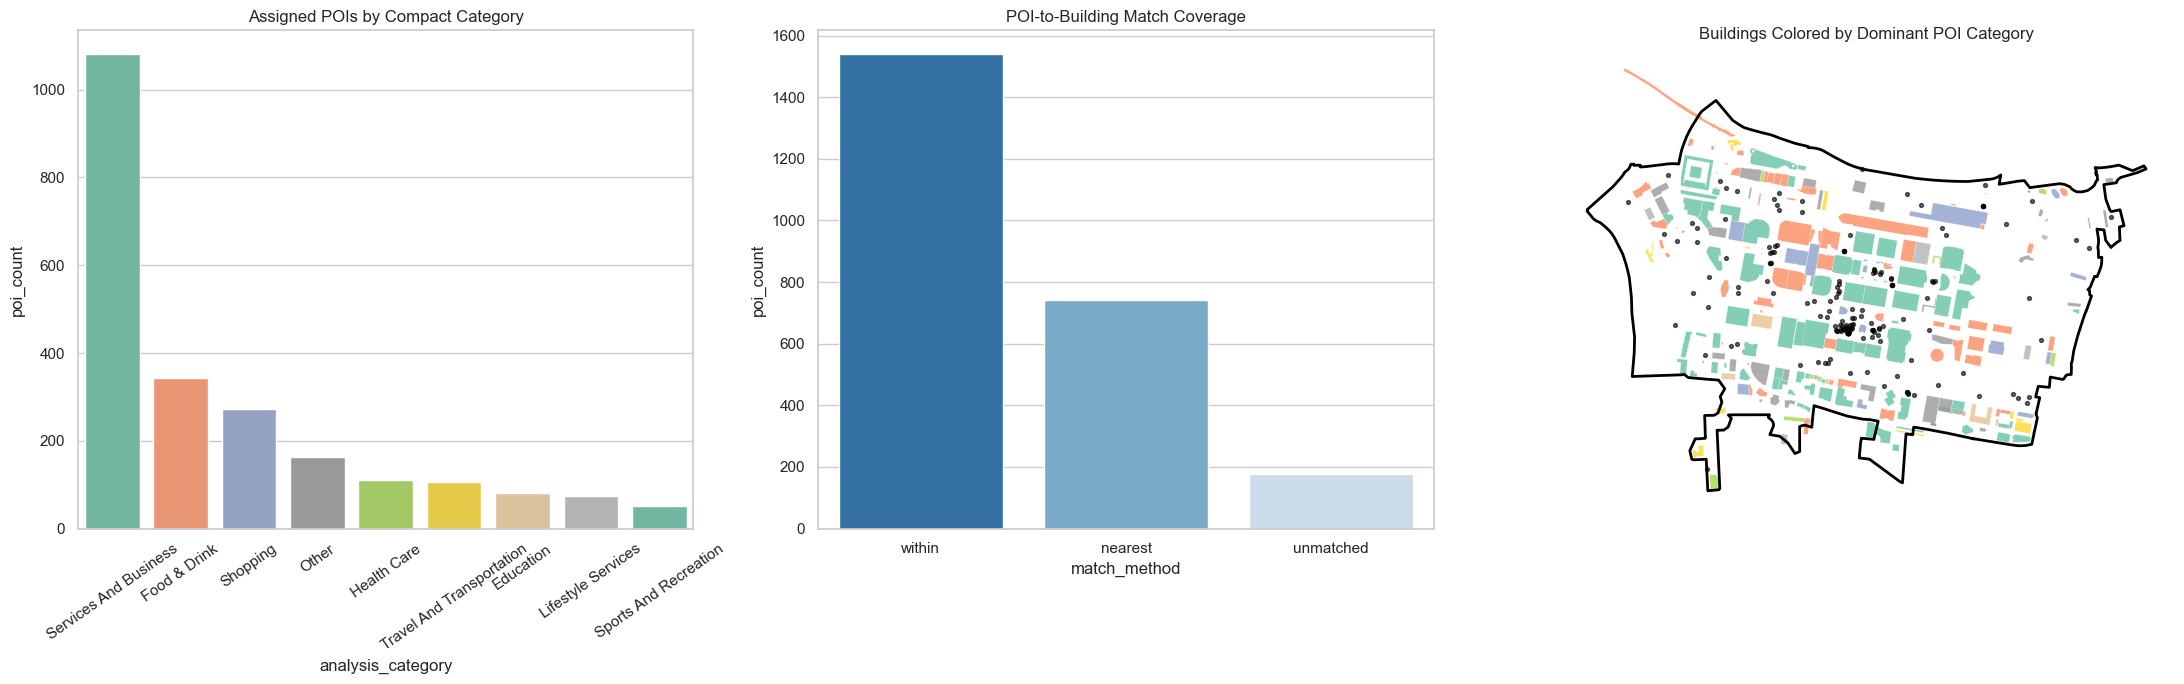

In [9]:
display_categories = [str(value) for value in assigned_analysis_category_limited.value_counts().index.tolist()]
palette_colors = sns.color_palette('Set2', n_colors=max(len(display_categories), 3)).as_hex()
category_palette = {category: color for category, color in zip(display_categories, palette_colors)}
category_palette['Other'] = '#999999'
category_palette['No matched POIs'] = '#d9d9d9'

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

category_bar = assigned_analysis_category_limited.value_counts().rename_axis('analysis_category').reset_index(name='poi_count')
sns.barplot(data=category_bar, x='analysis_category', y='poi_count', hue='analysis_category', palette=category_palette, legend=False, ax=axes[0])
axes[0].set_title('Assigned POIs by Compact Category')
axes[0].tick_params(axis='x', rotation=35)

coverage_plot = coverage_summary.reset_index(names='match_method')
sns.barplot(
    data=coverage_plot,
    x='match_method',
    y='poi_count',
    hue='match_method',
    palette='Blues_r',
    legend=False,
    ax=axes[1],
)
axes[1].set_title('POI-to-Building Match Coverage')

aoi.boundary.plot(ax=axes[2], color='black', linewidth=2)
building_plot_frame = pd.DataFrame(building_aoi)
building_plot_crs = building_aoi.crs
for category, color in category_palette.items():
    category_mask = (
        pd.Series(building_plot_frame['poi_sum'], index=building_plot_frame.index).gt(0)
        & pd.Series(building_plot_frame['dominant_category'], index=building_plot_frame.index).eq(category)
    )
    if category_mask.any():
        category_buildings = gpd.GeoDataFrame(
            building_plot_frame.loc[category_mask.to_numpy()].copy(),
            geometry='geometry',
            crs=building_plot_crs,
        )
        category_buildings.plot(ax=axes[2], color=color, edgecolor='white', linewidth=0.2, alpha=0.8)

place_plot_frame = pd.DataFrame(place_aoi)
place_plot_crs = place_aoi.crs
unmatched_place_mask = ~pd.Series(place_plot_frame['is_assigned_to_building'], index=place_plot_frame.index).astype(bool)
if unmatched_place_mask.any():
    unmatched_places = gpd.GeoDataFrame(
        place_plot_frame.loc[unmatched_place_mask.to_numpy()].copy(),
        geometry='geometry',
        crs=place_plot_crs,
    )
    unmatched_places.plot(ax=axes[2], color='black', markersize=8, alpha=0.6)

axes[2].set_title('Buildings Colored by Dominant POI Category')
axes[2].set_axis_off()

plt.tight_layout()
plt.show()


## Step 5: Interactive Map and HTML Export

The interactive map keeps the geometry simple and analyst-friendly:

- AOI boundary at the bottom.
- Buildings colored by dominant compact category.
- POIs in a marker cluster with name, `basic_category`, compact category, and match method.
- Building popups showing top category counts and a short list of matched place names.
- Exported HTML map in `output/`.


In [10]:
def summarize_building_popup(row: pd.Series, categories: list[str]) -> str:
    count_items = [(category, as_int(row.get(category))) for category in categories]
    count_items = [(category, count) for category, count in count_items if count > 0]
    count_items.sort(key=lambda item: item[1], reverse=True)
    total = sum(count for _, count in count_items)

    if total == 0:
        return (
            "<div style='font-size:12px;'><b>No matched POIs</b><br>"
            f"Building ID: {html.escape(series_text(row, 'id', default='n/a'))}</div>"
        )

    rows: list[str] = []
    for category, count in count_items:
        share = count / total * 100
        rows.append(
            f"<tr><td>{html.escape(str(category))}</td><td style='text-align:right'>{count}</td><td style='text-align:right'>{share:.1f}%</td></tr>"
        )

    sample_names = as_str_list(row.get('sample_place_names'))
    name_html = '<br>'.join(html.escape(str(value)) for value in sample_names[:8]) or 'No sample names'
    return (
        "<div style='font-size:12px; max-width:380px;'>"
        f"<b>Building ID:</b> {html.escape(series_text(row, 'id', default='n/a'))}<br>"
        f"<b>POIs assigned:</b> {total}<br>"
        f"<b>Dominant category:</b> {html.escape(series_text(row, 'dominant_category'))}<br><br>"
        "<table style='width:100%; border-collapse:collapse;'>"
        "<thead><tr><th style='text-align:left'>Category</th><th style='text-align:right'>Count</th><th style='text-align:right'>Share</th></tr></thead>"
        f"<tbody>{''.join(rows)}</tbody></table><br>"
        f"<b>Sample matched POIs</b><br>{name_html}</div>"
    )


building_web = building_aoi.to_crs(epsg=4326).copy()
building_web['tooltip_text'] = building_web.apply(build_building_tooltip, axis=1)
building_web['popup_html'] = building_web.apply(
    lambda row: summarize_building_popup(row, category_columns),
    axis=1,
)

place_web = place_aoi.to_crs(epsg=4326).copy()
place_web['primary_name'] = place_web['primary_name'].fillna('Unknown')
place_web['basic_category'] = place_web['basic_category'].fillna('Unknown')

center_lat = (aoi_bbox['south'] + aoi_bbox['north']) / 2
center_lon = (aoi_bbox['west'] + aoi_bbox['east']) / 2
interactive_map = folium.Map(location=[center_lat, center_lon], zoom_start=15, tiles='CartoDB positron', control_scale=True)

folium.GeoJson(
    aoi[['geometry']],
    name='AOI boundary',
    style_function=lambda _: {'color': '#000000', 'weight': 2, 'fillOpacity': 0},
).add_to(interactive_map)

background_buildings = folium.FeatureGroup(name='All buildings', show=True)
folium.GeoJson(
    building_web[['geometry']],
    style_function=lambda _: {'color': '#bbbbbb', 'weight': 0.3, 'fillColor': '#f0f0f0', 'fillOpacity': 0.15},
).add_to(background_buildings)
background_buildings.add_to(interactive_map)

categorized_buildings = folium.FeatureGroup(name='Categorized buildings', show=True)
for category, color in category_palette.items():
    if category == 'No matched POIs':
        continue
    category_slice = building_web[(building_web['poi_sum'] > 0) & (building_web['dominant_category'] == category)]
    if category_slice.empty:
        continue

    folium.GeoJson(
        category_slice[['id', 'tooltip_text', 'popup_html', 'geometry']],
        name=category,
        style_function=lambda _, c=color: {'color': c, 'weight': 0.6, 'fillColor': c, 'fillOpacity': 0.55},
        highlight_function=lambda _: {'weight': 2, 'fillOpacity': 0.8},
        tooltip=folium.GeoJsonTooltip(fields=['tooltip_text'], aliases=['building'], sticky=True, labels=True),
        popup=folium.GeoJsonPopup(fields=['popup_html'], labels=False, parse_html=True, max_width=420),
    ).add_to(categorized_buildings)

categorized_buildings.add_to(interactive_map)

poi_group = folium.FeatureGroup(name='POIs', show=True)
poi_cluster = MarkerCluster(name='POI cluster').add_to(poi_group)

poi_to_plot = place_web.copy()
if len(poi_to_plot) > max_poi_markers:
    poi_to_plot = poi_to_plot.sample(max_poi_markers, random_state=42)

for _, row in poi_to_plot.iterrows():
    point = point_from_row(row)
    if point is None:
        continue

    tooltip_html = build_poi_tooltip(row)

    marker_color = category_palette.get(series_text(row, 'analysis_category_limited'), '#666666')
    folium.CircleMarker(
        location=[point.y, point.x],
        radius=3,
        color=marker_color,
        fill=True,
        fill_color=marker_color,
        fill_opacity=0.85,
        weight=1,
        tooltip=folium.Tooltip(tooltip_html),
    ).add_to(poi_cluster)

poi_group.add_to(interactive_map)
folium.LayerControl(collapsed=False).add_to(interactive_map)

if export_map_html:
    map_html_path = output_dir / 'overture_poi_building_map.html'
    interactive_map.save(map_html_path)
    print(f'Interactive map exported to: {map_html_path}')

display(interactive_map)


Interactive map exported to: /Users/ruoyuli/Documents/0 RLi Documents/Study/NYU/00 Capstone/workspace/Overture/output/overture_poi_building_map.html
